# Test of the Reciever Simulator


In [28]:
from simulation.observation_handler import ObservationHandler
from simulation.loads import Load
from simulation.receiver import Receiver

import matplotlib.pyplot as plt
import numpy as np
import astropy.units as un

import os

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

In [29]:
test_receiver = Receiver(gamma_rec_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlockSDR0.s2p',
                         gains_s2p_path='/Users/user/Desktop/RHINO/new_daq/VNA_Measurements_John/RecBlock/RecBlock0.s2p')

test_receiver.change_freqs(np.linspace(60*un.MHz, 80*un.MHz, 1024))

open_load = Load(physical_temperature=273,
                 label='open',
                 termination_type='open',
                 freqs=test_receiver.freqs)

short_load = Load(physical_temperature=273,
                 label='short',
                 termination_type='short',
                 freqs=test_receiver.freqs)

long_open = Load(physical_temperature=273,
                 label='long_open',
                 termination_type='open',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

long_short = Load(physical_temperature=273,
                 label='long_short',
                 termination_type='short',
                 effective_cable_length=3*un.m,
                 freqs=test_receiver.freqs)

matched_ambient = Load(physical_temperature=273,
                       label='internal_load',
                       termination_type='matched',
                       freqs=test_receiver.freqs)

heated_load = Load(physical_temperature=matched_ambient.t_src+40,
                      label='heated_load',
                      termination_type='matched',
                      freqs=test_receiver.freqs)


test_src = Load(physical_temperature=350,
                termination_impedence=75*un.Ohm,
                freqs=test_receiver.freqs,
                effective_cable_length=5*un.m,
                label='Test_src')


observation_handler_obj = ObservationHandler(observation_length=6*3600*un.s,
                                             receiver=test_receiver,
                                             sources=[long_open,
                                                      long_short,
                                                      open_load,
                                                      short_load,
                                                      test_src,
                                                      test_src,
                                                      test_src,
                                                      test_src],
                                            dicke_switch_sources=[matched_ambient,
                                                                  heated_load],
                                            dicke_switch_length=300*un.s,
                                            delta_t=10*un.s,
                                            n_t_unc_freq_coeffs=5,
                                            n_t_unc_time_coeffs=2,
                                            n_t_sin_freq_coeffs=3,
                                            n_t_sin_time_coeffs=3,
                                            n_t_cos_freq_coeffs=4,
                                            n_t_cos_time_coeffs=4)



Done


In [30]:
os.makedirs('simulated_data',
          exist_ok=True)

observation_handler_obj.save_to_hdf5(filepath="simulated_data/sim_data.hdf5")
open_load.export_to_s2p('simulated_data')
short_load.export_to_s2p('simulated_data')
long_open.export_to_s2p('simulated_data')
long_short.export_to_s2p('simulated_data')
matched_ambient.export_to_s2p('simulated_data')
heated_load.export_to_s2p('simulated_data')
test_src.export_to_s2p('simulated_data')
test_receiver.export_to_s2p('simulated_data')

/Users/user/Desktop/RHINO/rhino-cal/simulation/loads.py:101: RuntimeWarning: invalid value encountered in sqrt
  s21 = np.sqrt(1 - np.abs(s11)**2)


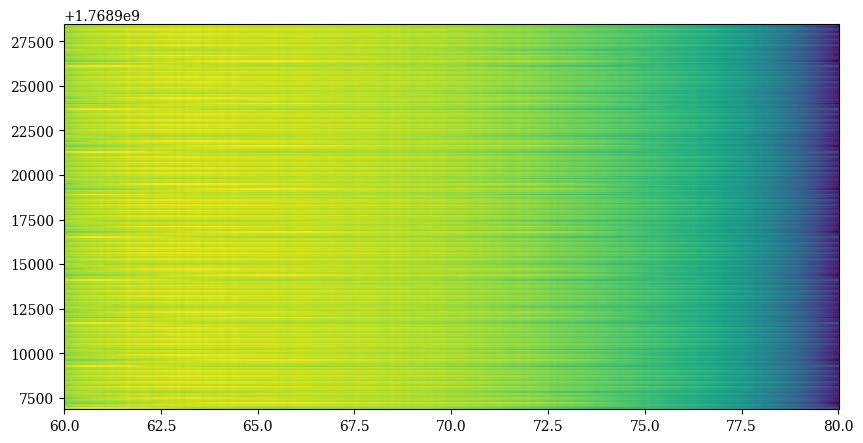

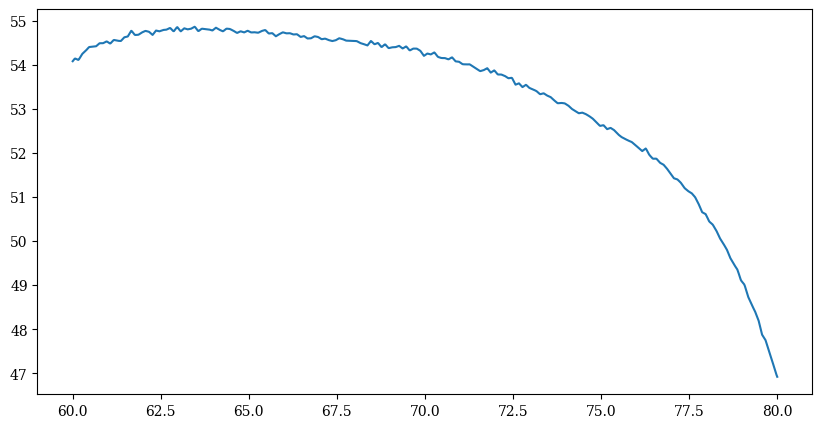

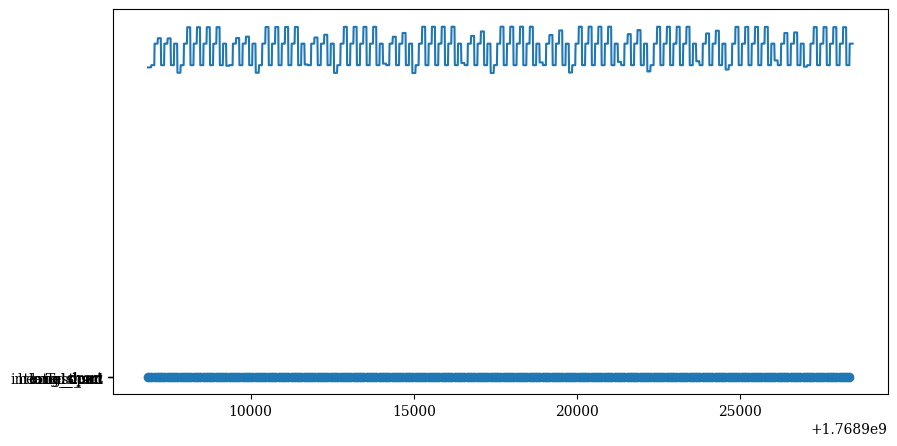

<class 'str'>
<class 'numpy.float64'>
internal_load
[272.83494087 273.14038782 272.98940581 ... 272.88898342 273.0065139
 273.03810627]
----
heated_load
[313.04662457 312.95854568 313.13757824 ... 312.91989143 313.0434148
 313.02357961]
----
long_open
[273.01613289 273.09994732 272.87847936 ... 273.09455697 272.9692021
 273.01426542]
----
long_short
[273.15321011 272.9499317  273.00526965 ... 272.81773296 272.99671292
 272.99376385]
----
open
[272.97221516 272.85372553 273.13747635 ... 273.05853062 272.89226414
 273.0748825 ]
----
short
[272.79188416 273.0470074  272.97661484 ... 273.01229743 272.98922773
 272.8793511 ]
----
Test_src
[349.99061633 350.02313298 350.10140727 ... 350.19949949 349.98947515
 350.00300701]
----


In [31]:

plt.pcolormesh(np.array(observation_handler_obj.freqs),
               np.array(observation_handler_obj.times),
               10*np.log10(observation_handler_obj.data))
plt.show()

plt.plot(observation_handler_obj.freqs,10*np.log10(np.mean(observation_handler_obj.data, axis=0)))
plt.show()

plt.plot(observation_handler_obj.times, observation_handler_obj.data.sum(axis=1))
plt.scatter(observation_handler_obj.switch_times, observation_handler_obj.switch_states)
plt.show()

print(type(observation_handler_obj.switch_states[0]))
print(type(observation_handler_obj.switch_times[0]))


for i, k in observation_handler_obj.temperature_dict.items():
    print(i)
    print(k)
    print('----')


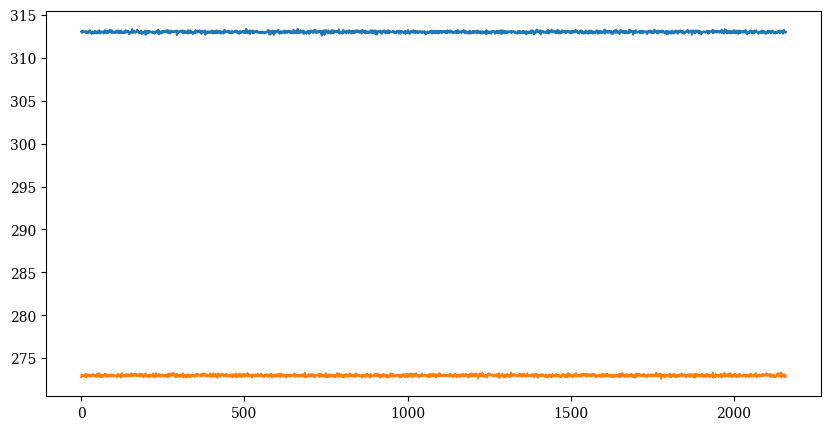

In [32]:
plt.plot(observation_handler_obj.temperature_dict['heated_load'])
plt.plot(observation_handler_obj.temperature_dict['short'])

In [33]:
print(observation_handler_obj.data.shape)
print(observation_handler_obj.data)

(2160, 1024)
[[302806.02036866 305715.38443058 306994.84140755 ...  64022.85150869
   63770.82700043  63111.44845657]
 [303756.38203241 304447.73172827 306768.73344771 ...  63781.85299387
   63336.22124833  63425.30602129]
 [302532.64824879 302985.97929445 305825.91154196 ...  63824.00770469
   63737.9965239   63214.31138181]
 ...
 [260170.80160403 260885.39099813 262800.38639036 ...  50228.84568599
   49779.81799196  49151.19814561]
 [260454.46134963 261249.04263521 261979.34817004 ...  50364.81241855
   49668.60566894  49050.42496114]
 [259781.11065343 260513.2806782  262592.76492414 ...  50494.31953157
   49686.33845312  49317.73217123]]


In [34]:
from gcr.data_processing import create_nw_data_and_covariance_from_raw
from gcr.transfer_matrix_construction import construct_transfer_matrix


data_waterfall, covar_waterfall, final_times, final_states = create_nw_data_and_covariance_from_raw(waterfall=observation_handler_obj.data,
                                                                             times=observation_handler_obj.times,
                                                                             freqs=observation_handler_obj.freqs,
                                                                             switch_times=observation_handler_obj.switch_times,
                                                                             switch_states=observation_handler_obj.switch_states,
                                                                             source_temperatures=observation_handler_obj.temperature_dict,
                                                                             gamma_src_dict=observation_handler_obj.gamma_src_dict,
                                                                             noise_wave_loads=['open',
                                                                                               'short',
                                                                                               'long_open',
                                                                                               'long_short'],
                                                                            internal_load_label='internal_load',
                                                                            noise_source_label='heated_load',
                                                                            switch_buffer=2*un.s,
                                                                            gamma_rec=observation_handler_obj.gamma_rec)


0 0 long_open 1768906853.5738704 s
0 1 internal_load 1768906953.5738704 s
0 2 heated_load 1768907053.5738704 s
1 0 long_short 1768907153.5738704 s
1 1 internal_load 1768907253.5738704 s
1 2 heated_load 1768907353.5738704 s
2 0 open 1768907453.5738704 s
2 1 internal_load 1768907553.5738704 s
2 2 heated_load 1768907653.5738704 s
3 0 short 1768907753.5738704 s
3 1 internal_load 1768907853.5738704 s
3 2 heated_load 1768907953.5738704 s
8 0 long_open 1768909253.5738704 s
8 1 internal_load 1768909353.5738704 s
8 2 heated_load 1768909453.5738704 s
9 0 long_short 1768909553.5738704 s
9 1 internal_load 1768909653.5738704 s
9 2 heated_load 1768909753.5738704 s
10 0 open 1768909853.5738704 s
10 1 internal_load 1768909953.5738704 s
10 2 heated_load 1768910053.5738704 s
11 0 short 1768910153.5738704 s
11 1 internal_load 1768910253.5738704 s
11 2 heated_load 1768910353.5738704 s
16 0 long_open 1768911653.5738704 s
16 1 internal_load 1768911753.5738704 s
16 2 heated_load 1768911853.5738704 s
17 0 lon

In [35]:
print(final_states)

[np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short'), np.str_('long_open'), np.str_('long_short'), np.str_('open'), np.str_('short')]


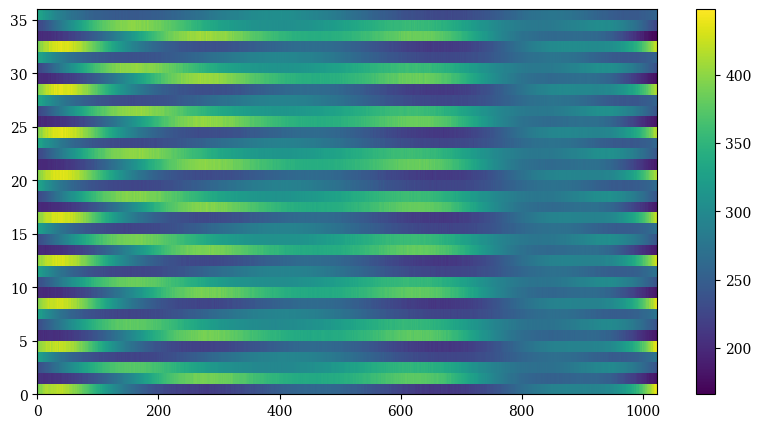

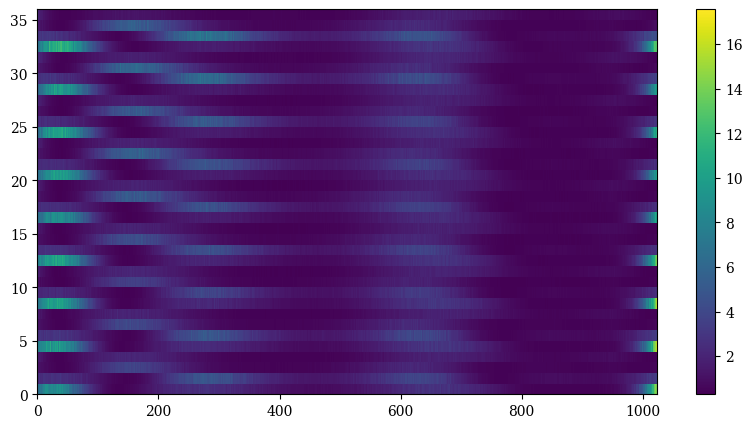

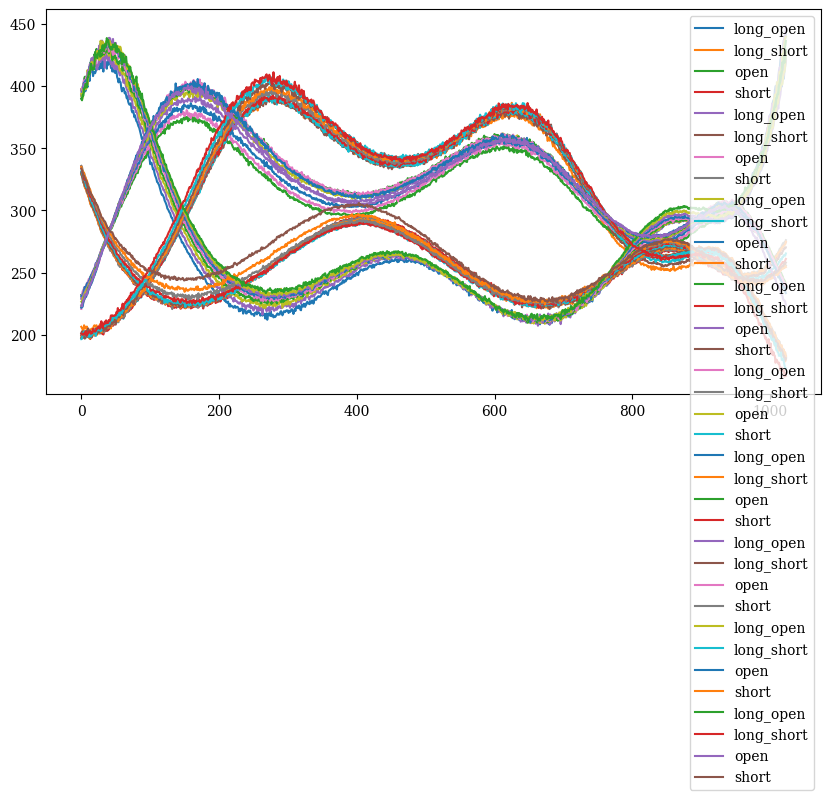

In [36]:
plt.pcolormesh(data_waterfall)
plt.colorbar()
plt.show()

plt.pcolormesh(covar_waterfall)
plt.colorbar()
plt.show()

for l, state in zip(data_waterfall, final_states):
    plt.plot(l, label=state)
plt.legend()
plt.show()



In [37]:
print(type(final_times[0]))

example_time = 100 *un.day

float_time = float(example_time.to(un.s) / un.s)

print(float_time)

<class 'float'>
8640000.0


In [38]:
unc_coeffs_deg = (5,5)
cos_coeffs_deg = (5,5)
sin_coeffs_deg = (5,5)

print(np.array(observation_handler_obj.freqs[0]))
print(type(np.array(observation_handler_obj.freqs[0])))

print(final_times[0])
print(type(np.array(final_times[0])))

transfer_matrix, (freq_norm, time_norm) = construct_transfer_matrix(np.array(observation_handler_obj.freqs),
                                            np.array(final_times),
                                            switch_states_array=final_states,
                                            unc_poly_orders=unc_coeffs_deg,
                                            cos_poly_orders=cos_coeffs_deg,
                                            sin_poly_orders=sin_coeffs_deg,
                                            switch_state_src_gamma_dict=observation_handler_obj.gamma_src_dict,
                                            gamma_rec=observation_handler_obj.gamma_rec,
                                            return_norm_funcs=True)

print(freq_norm)


60.0
<class 'numpy.ndarray'>
1768907003.643347
<class 'numpy.ndarray'>
<function array_normalisation.<locals>.array_norm_func at 0x16c4ef600>


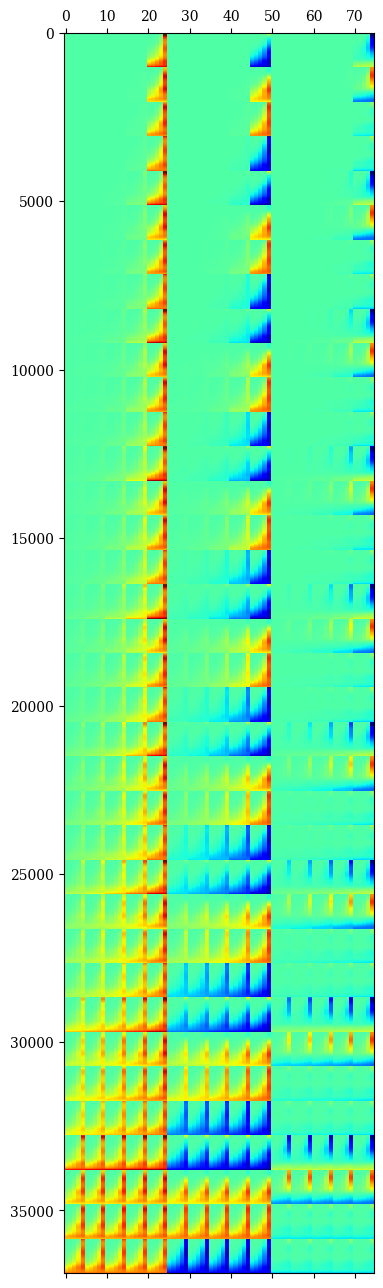

In [39]:
plt.matshow(transfer_matrix, aspect='auto', cmap='jet')
plt.show()

(36864,)
(36864, 75)
[-3.55126101e+02  6.07064136e+02 -3.37438040e+02  7.78137532e+01
 -6.78866186e+00  6.95886746e+02 -1.14904409e+03  5.98683799e+02
 -1.24170024e+02  9.79190544e+00 -4.11753632e+02  6.32783224e+02
 -2.84026205e+02  4.37757804e+01 -2.29786642e+00 -1.20941848e+03
  2.51799844e+03 -1.70197099e+03  3.87676108e+02 -4.25182797e+00
  1.14927857e+03 -2.09012682e+03  1.17633189e+03 -2.19064459e+02
  3.02386076e+02 -1.21564941e+02  2.96659641e+02 -2.28529730e+02
  4.97517960e+01  5.77084355e+00  9.80172973e+01 -2.46443393e+03
  3.54572882e+03 -1.36758343e+03  5.53005397e+01  8.10512260e+01
  2.65244895e+03 -4.07324929e+03  1.60459092e+03 -9.19670421e+01
 -7.83066946e+01 -4.84709037e+02  7.71442717e+02 -2.78455696e+02
  2.51665509e+01  8.99836122e+00 -1.01198851e+02  1.36953007e+02
 -5.37826779e+01  2.39422181e+01  4.16363700e+01 -4.39599491e+02
  5.54072115e+02 -1.86907580e+02  1.46340499e+01  4.07858046e+01
  5.85140596e+02 -8.94925732e+02  3.30033625e+02 -2.71475620e+01
 -1.

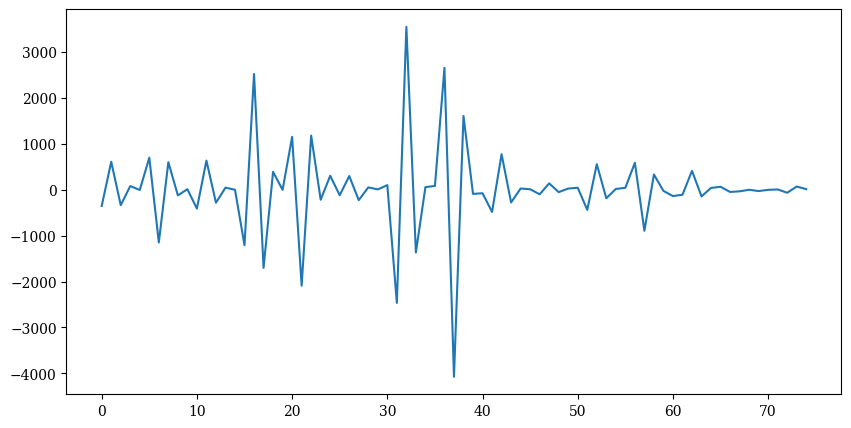

In [40]:
flattened_data = data_waterfall.flatten()

print(flattened_data.shape)
print(transfer_matrix.shape)

t_vec = np.linalg.lstsq(transfer_matrix, flattened_data)[0]


plt.plot(t_vec)


print(t_vec)

In [41]:
from gcr.basis_construction import reconstruct_surface

In [42]:
n_t_unc_coeffs = unc_coeffs_deg[0]*unc_coeffs_deg[-1]
n_t_cos_coeffs = cos_coeffs_deg[0]*cos_coeffs_deg[-1]
n_t_sin_coeffs = sin_coeffs_deg[0]*sin_coeffs_deg[-1]


t_unc_coeffs = t_vec[:n_t_unc_coeffs]
t_cos_coeffs = t_vec[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = t_vec[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)

[-3.55126101e+02  6.07064136e+02 -3.37438040e+02  7.78137532e+01
 -6.78866186e+00  6.95886746e+02 -1.14904409e+03  5.98683799e+02
 -1.24170024e+02  9.79190544e+00 -4.11753632e+02  6.32783224e+02
 -2.84026205e+02  4.37757804e+01 -2.29786642e+00 -1.20941848e+03
  2.51799844e+03 -1.70197099e+03  3.87676108e+02 -4.25182797e+00
  1.14927857e+03 -2.09012682e+03  1.17633189e+03 -2.19064459e+02
  3.02386076e+02]
[ -121.56494138   296.65964077  -228.52972966    49.75179602
     5.77084355    98.01729734 -2464.43393452  3545.72882431
 -1367.5834286     55.30053971    81.051226    2652.4489465
 -4073.24928711  1604.59092174   -91.96704208   -78.30669461
  -484.7090369    771.44271671  -278.45569617    25.16655093
     8.99836122  -101.19885096   136.95300725   -53.78267789
    23.94221805]
[  41.63637002 -439.5994914   554.07211464 -186.9075796    14.63404989
   40.78580462  585.14059562 -894.92573171  330.03362531  -27.14756203
 -139.5713495  -110.57989656  409.77916312 -146.43423691   37.876706

In [43]:

t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


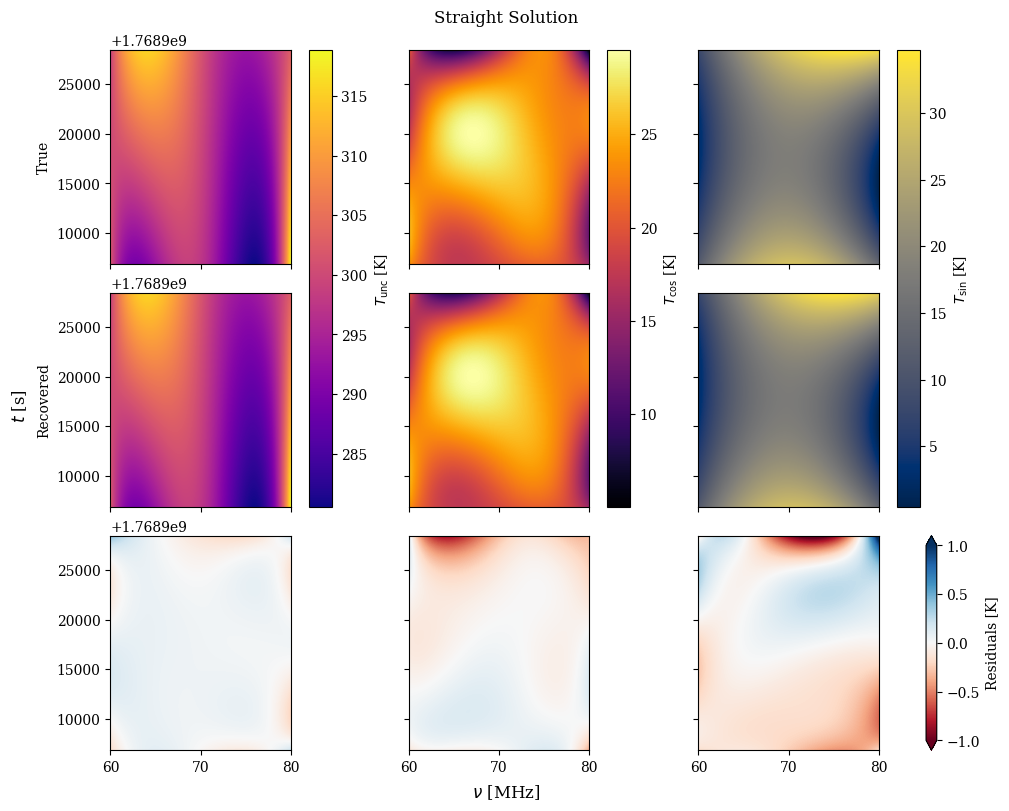

In [44]:
# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)

resid_vminmax = 1

unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Straight Solution')
plt.show()


In [45]:
flat_cov = covar_waterfall.flatten()
inv_cov = 1 / flat_cov

from gcr.noise_wave_gcr import construct_gcr_lhs, construct_gcr_rhs
from scipy.sparse.linalg import cg


S_cov = np.abs(t_vec) / 2
S_inv = np.zeros_like(t_vec)# 1/S_cov
S_inv = 1/S_cov #  np.zeros_like(t_vec)# 1/S_cov

lhs = construct_gcr_lhs(transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv)

rhs = construct_gcr_rhs(d=flattened_data,
                        H_matrix=transfer_matrix,
                        N_inv_1d=inv_cov,
                        S_inv=S_inv,
                        T_nw0=t_vec,
                        omega_d=np.random.normal(loc=0, scale=1, size=flattened_data.shape),
                        omega_t=np.random.normal(loc=0, scale=1, size=t_vec.shape))

gcr_wsol = cg(lhs, rhs, x0=t_vec)[0]


In [46]:
t_unc_coeffs = gcr_wsol[:n_t_unc_coeffs]
t_cos_coeffs = gcr_wsol[n_t_unc_coeffs:n_t_unc_coeffs+n_t_cos_coeffs]
t_sin_coeffs = gcr_wsol[n_t_unc_coeffs+n_t_cos_coeffs:]

print(t_unc_coeffs)
print(t_cos_coeffs)
print(t_sin_coeffs)


t_unc_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_unc_coeffs,
                                    n_x_coeffs=unc_coeffs_deg[0],
                                    n_y_coeffs=unc_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_cos_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_cos_coeffs,
                                    n_x_coeffs=cos_coeffs_deg[0],
                                    n_y_coeffs=cos_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)

t_sin_surface = reconstruct_surface(x=np.array(observation_handler_obj.freqs),
                                    y=np.array(observation_handler_obj.times),
                                    flat_coeffs=t_sin_coeffs,
                                    n_x_coeffs=sin_coeffs_deg[0],
                                    n_y_coeffs=sin_coeffs_deg[-1],
                                    x_array_norm_func=freq_norm,
                                    y_array_norm_func=time_norm)


[-3.55123264e+02  6.07071521e+02 -3.37431778e+02  7.78171226e+01
 -6.80666487e+00  6.95890944e+02 -1.14903933e+03  5.98691936e+02
 -1.24168640e+02  9.77542373e+00 -4.11752147e+02  6.32789518e+02
 -2.84020174e+02  4.37802338e+01 -2.31452083e+00 -1.20941767e+03
  2.51800447e+03 -1.70196419e+03  3.87684270e+02 -4.25919014e+00
  1.14926839e+03 -2.09013668e+03  1.17632817e+03 -2.19063177e+02
  3.02388034e+02]
[ -121.57205451   296.65317861  -228.53934535    49.74570033
     5.7801588     98.01389766 -2464.44135407  3545.7220467
 -1367.59153603    55.30723577    81.05044451  2652.44608539
 -4073.25611061  1604.58575583   -91.96635207   -78.30284855
  -484.70733669   771.44395305  -278.45895981    25.16251705
     9.02551492  -101.17768515   136.9700977    -53.78172588
    23.89208472]
[  41.62952169 -439.60952277  554.06300443 -186.91835676   14.63921339
   40.77757388  585.13115232 -894.93848131  330.02339595  -27.14487978
 -139.58338609 -110.59328797  409.76637015 -146.44857954   37.882135

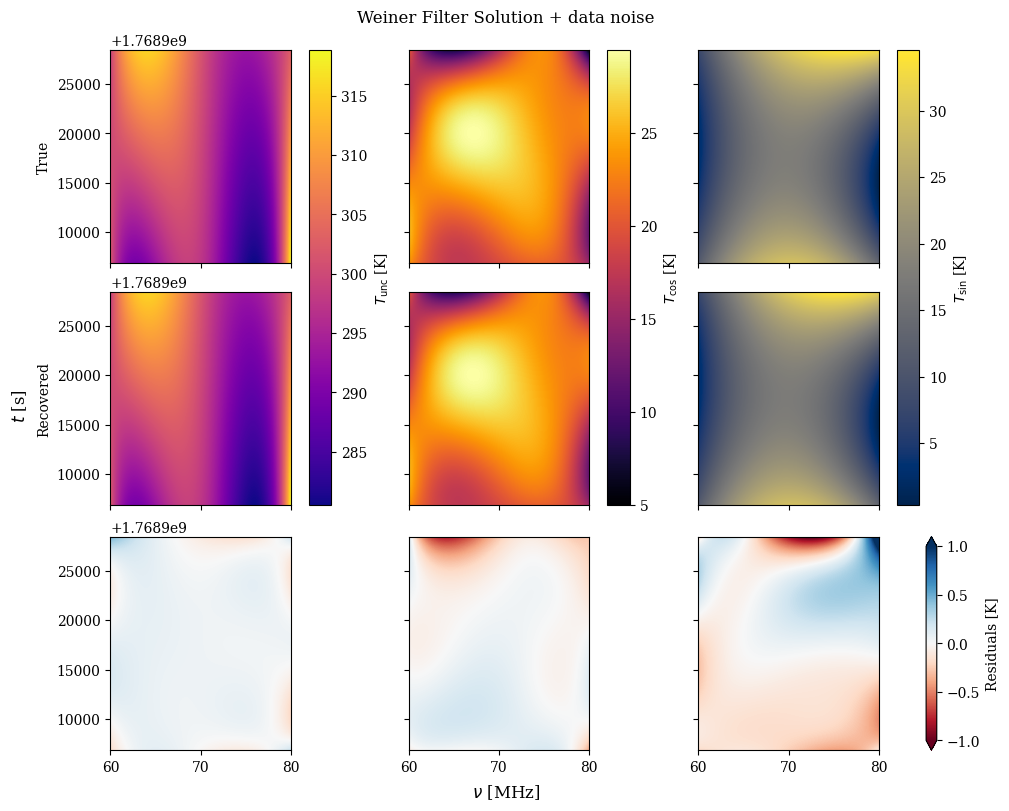

In [47]:

# Plot Residuals and Reconstructed Surface
fig, axes = plt.subplots(nrows=3,
                         ncols=3,
                         sharex=True,
                         layout='constrained',
                         figsize=(10,8),
                         sharey=True)


unc = axes[0,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc,
                     cmap='plasma')

unc = axes[1,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_unc_surface,
                     cmap='plasma')

res = axes[2,0].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_unc - t_unc_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

cos = axes[0,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos,
                     cmap='inferno')

cos = axes[1,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_cos_surface,
                     cmap='inferno')

res = axes[2,1].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_cos - t_cos_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')

sin = axes[0,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin,
                     cmap='cividis')

sin  = axes[1,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     t_sin_surface,
                     cmap='cividis')

res = axes[2,2].pcolormesh(np.array(observation_handler_obj.freqs),
                     np.array(observation_handler_obj.times),
                     observation_handler_obj.t_sin - t_sin_surface,
                     vmin=-resid_vminmax,
                     vmax=resid_vminmax,
                     cmap='RdBu')


axes[0,0].set_ylabel('True')
axes[1,0].set_ylabel('Recovered')


fig.colorbar(res,
             ax=[axes[2,i] for i in range(3)],
             label='Residuals [K]',
             extend='both')

fig.colorbar(unc,
             ax=[axes[i,0] for i in range(2)],
             label=r'$T_{\rm unc}$ [K]')

fig.colorbar(cos,
             ax=[axes[i,1] for i in range(2)],
             label=r'$T_{\rm cos}$ [K]')

fig.colorbar(sin,
             ax=[axes[i,2] for i in range(2)],
             label=r'$T_{\rm sin}$ [K]')

fig.supxlabel(r'$\nu$ [MHz]')
fig.supylabel(r'$t$ [s]')
fig.suptitle('Weiner Filter Solution + data noise')
plt.show()


In [48]:
t_vec - gcr_wsol

array([-0.00283732, -0.00738562, -0.00626203, -0.00336934,  0.01800301,
       -0.00419789, -0.00475536, -0.00813675, -0.00138444,  0.01648171,
       -0.00148594, -0.006294  , -0.00603101, -0.00445347,  0.01665441,
       -0.00081043, -0.00603464, -0.0068052 , -0.0081623 ,  0.00736216,
        0.01017843,  0.00985305,  0.00372317, -0.00128258, -0.00195821,
        0.00711314,  0.00646216,  0.00961569,  0.00609569, -0.00931525,
        0.00339968,  0.00741955,  0.00677761,  0.00810743, -0.00669606,
        0.00078149,  0.00286111,  0.00682351,  0.00516591, -0.00069001,
       -0.00384606, -0.00170021, -0.00123634,  0.00326364,  0.00403389,
       -0.0271537 , -0.02116581, -0.01709045, -0.00095201,  0.05013333,
        0.00684832,  0.01003137,  0.00911021,  0.01077716, -0.0051635 ,
        0.00823073,  0.0094433 ,  0.0127496 ,  0.01022936, -0.00268225,
        0.01203659,  0.01339141,  0.01279297,  0.01434263, -0.00542894,
        0.01238132,  0.01612992,  0.01790624,  0.01786717, -0.00

In [49]:
from MomentRFI.MomentRFI import load_waterfall, validate_waterfall, IterativeSurfaceFitter
from MomentRFI.MomentRFI.plotting import plot_summary